# Text Preprocessing and Embedding Generation
Dataset: BBC News (5 Categories)

In [2]:
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /home/asish-jose/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/asish-
[nltk_data]     jose/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/asish-
[nltk_data]     jose/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Load Dataset

In [12]:
df = pd.read_csv("../../data/bbc-news-data.csv", sep="\t")

df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [14]:
df.shape

(2225, 4)

In [15]:
df['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [16]:
df['text'] = df['title'] + " " + df['content']

## Text Preprocessing

In [21]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)  
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    tokens = word_tokenize(text)
    
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return " ".join(tokens)

In [22]:
df['clean_text'] = df['text'].apply(preprocess)

df[['text', 'clean_text']].head()

,text,clean_text
0,Ad sales boost Time Warner profit Quarterly p...,ad sale boost time warner profit quarterly pro...
1,Dollar gains on Greenspan speech The dollar h...,dollar gain greenspan speech dollar hit highes...
2,Yukos unit buyer faces loan claim The owners ...,yukos unit buyer face loan claim owner embattl...
3,High fuel prices hit BA's profits British Air...,high fuel price hit ba profit british airway b...
4,Pernod takeover talk lifts Domecq Shares in U...,pernod takeover talk lift domecq share uk drin...


## Vocabulary Analysis

In [23]:
raw_vocab = set(" ".join(df['text']).split())
clean_vocab = set(" ".join(df['clean_text']).split())

print("Raw Vocabulary Size:", len(raw_vocab))
print("Clean Vocabulary Size:", len(clean_vocab))

Raw Vocabulary Size: 65553
Clean Vocabulary Size: 27908


## TF-IDF Embedding Generation

In [24]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = vectorizer.fit_transform(df['clean_text'])

print("Embedding Shape:", X_tfidf.shape)

Embedding Shape: (2225, 5000)


## Sparsity

In [25]:
sparsity = 1.0 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print("Sparsity:", sparsity)

Sparsity: 0.9742071011235955


## Top Important Words (Globally)

In [26]:
feature_names = vectorizer.get_feature_names_out()

tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

top_indices = tfidf_scores.argsort()[-20:][::-1]

top_words = [feature_names[i] for i in top_indices]
top_scores = tfidf_scores[top_indices]

pd.DataFrame({"Word": top_words, "Score": top_scores})

,Word,Score
0,said,0.043665
1,mr,0.028257
2,year,0.023444
3,would,0.020621
4,film,0.019639
5,game,0.019249
6,people,0.018205
7,new,0.017771
8,also,0.017571
9,one,0.015884


## Category-wise Average Embedding Insight

In [27]:
category_means = {}

for category in df['category'].unique():
    category_means[category] = X_tfidf[df['category'] == category].mean()

print(category_means.keys())

AttributeError: 'Series' object has no attribute 'nonzero'

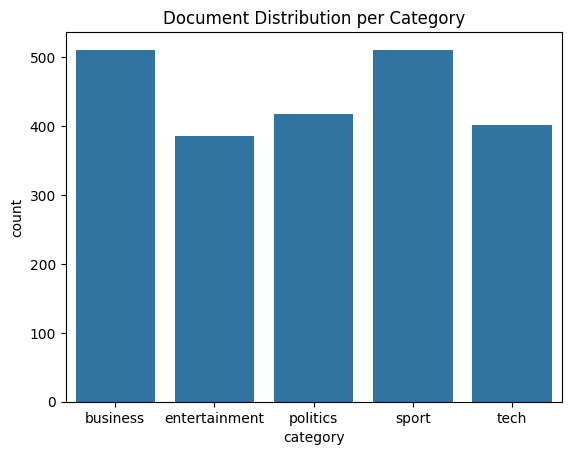

In [28]:
sns.countplot(x='category', data=df)
plt.title("Document Distribution per Category")
plt.show()

In [29]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

sentence_embeddings = model.encode(df['clean_text'])

print("Sentence Embedding Shape:", sentence_embeddings.shape)

ModuleNotFoundError: No module named 'sentence_transformers'

Vocabulary reduced after preprocessing

Stopword removal reduced noise

TF-IDF created sparse high-dimensional vectors

Sentence embeddings created dense semantic vectors

Embeddings capture topic-level distinctions